# Diabetes Analysis - Tuning Experiments

## Overview

This notebook contains preprocessing, feature engineering, and hyperparameter tuning experiments on the UC Irvine [*Diabetes 130-US Hospitals for Years 1999-2008*](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) dataset. The purpose of this analysis is to determine the pipeline hyperparameters that will maximize the recall of hospital readmission predictions, in order to capture more patients at risk of needing care within 30 days of discharge. Specifically, we will run three experiments to select among five classifier models, three sampling methods, and three feature selection techniques. The sampling experiment is especially important, as this dataset is heavily imbalanced. 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [149]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## Load Dataset

In [39]:
path = "../data/diabetic_data.csv"
df = pd.read_csv(path, low_memory=False)

with pd.option_context('display.max_columns', None):
    display(df.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Data Cleaning

This section repeats the steps taken in our preprocessing notebook. The first of these is to convert the target column, *readmitted*, to a binary (1 if readmitted within 30 days, 0 otherwise).

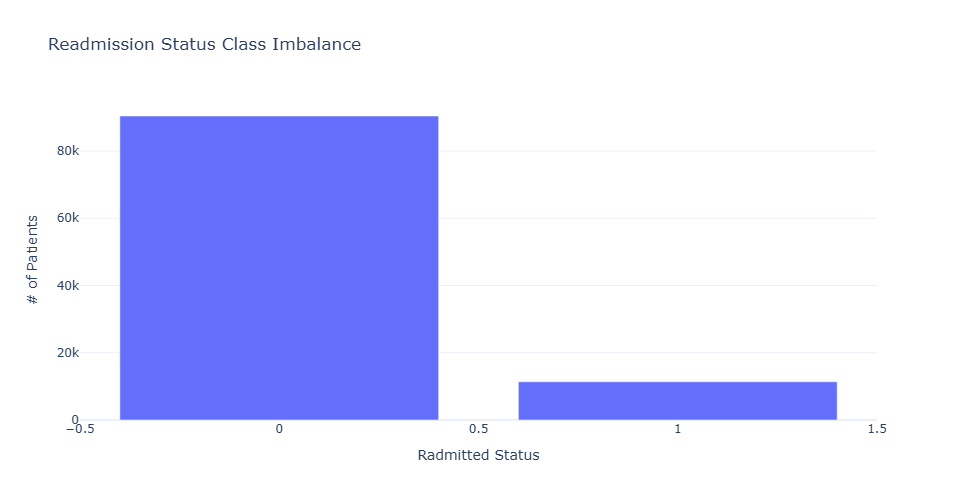

In [42]:
df["readmitted"] = df["readmitted"].map({
    "<30": 1,  # readmitted before 30 days 
    ">30": 0,  # readmitted after 30 days 
    "NO": 0
})

#Plots the count of each target class value
fig = px.bar(df['readmitted'].value_counts(), template = 'plotly_white', height = 500, width = 800,
            title = 'Readmission Status Class Imbalance')
fig.update_layout(showlegend = False, xaxis_title = 'Radmitted Status', yaxis_title = '# of Patients')
fig.show()

The positive class represents only 10% of the overall data. We will need to be careful about how we evaluate model performance: predicting 0 for all patients will result in high accuracy, but poor recall and precision. 

Missing values in string features are represented as '?'. To ensure that Pandas functions for handling NA values work on these rows, we will replace the missing values with np.nan. This will allow us to properly detect the proportion of missing values across all columns.

In [45]:
#Replaces missing strings with NAN, ensuring all missing values are handled correctly
df.replace('?', np.nan, inplace=True)

#Counts the proportion of NA values across all columns
na_prop = (df.isna().sum() / len(df)).to_frame(name='pct_rows')
#Displays the proportion of missing information across all features with NA values
display(na_prop[na_prop['pct_rows'] > 0].sort_values(by = 'pct_rows', ascending = False))

,pct_rows
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206


weight, max_glu_serum, and A1Cresult are missing too many values to be useful. We don't have any other features to calculate patient weight, such as height and BMI, so this will have to be dropped. max_glu_serum and A1Cresult will be used for feature engineering, then dropped. The rest can be imputed.

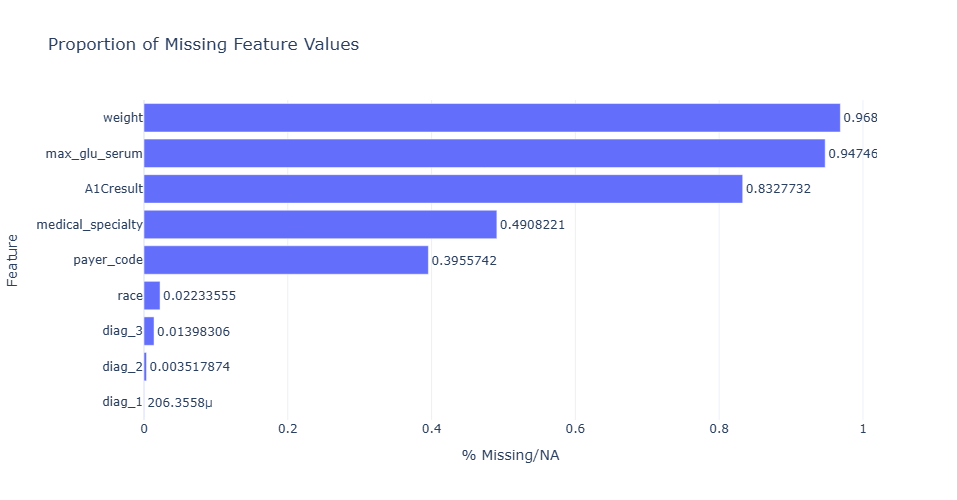

In [48]:
fig = px.bar(na_prop[na_prop['pct_rows'] > 0], x = 'pct_rows', height = 500, width = 800, template = 'plotly_white',
            title = 'Proportion of Missing Feature Values', text_auto = True)
fig.update_layout(xaxis_title = '% Missing/NA', yaxis_title = 'Feature')
fig.update_traces(textposition='outside')
fig.update_yaxes(categoryorder='total ascending')
fig.show()

## Feature Engineering

While we lack test results, we may be able to gleam useful information from knowing that a patient received a blood test. This may indicate the level of care they received, or the state of their condition that required further testing. For that reason, we will convert these features into binary features - glu_tested and A1C_tested - that measure whether or not these values are NA. 

Our EDA found that time_in_hospital and num_medications are correlated with one another and positively correlated with the target feature. We will combine these into an engineered feature, severity, that measures the state of a patient's condition during their hospitalization.

In [52]:
df['glu_tested'] = ~df['max_glu_serum'].isna()
df['A1C_tested'] = ~df['A1Cresult'].isna()

df['severity'] = df['time_in_hospital'] * (df['num_medications'] + 1)

There are over 700 unique ICD9 codes across the diagnosis columns (diag_1, diag_2, diag_3). We will be using one-hot encoding to preprocess these features, and doing so with so many unique values will result in hundreds of sparse features. Therefore, we will group each ICD9 code into one of nine conditions, reducing the size of our feature space. 

In [55]:
def match_icd9_group(diag_col):
    #ICD9 codes referring to an external cause begin with a letter E-V. I'll replace all of these with numeric values using regex
    diag_col = diag_col.str.replace(r'[E-V]\d*', '1000', regex = True).astype(float)

    #Matches each condition with its ICD9 grouping
    conditions = [
        (diag_col.between(390, 459)) | (diag_col == 785), #circulatory
        (diag_col.between(460, 519)) | (diag_col == 786), #respiratory
        (diag_col.between(520, 579)) | (diag_col == 787), #digestive
        np.floor(diag_col) == 250, #diabetes
        diag_col.between(800, 999), #injury
        diag_col.between(710, 739), #musculoskeletal
        (diag_col.between(580, 629)) | (diag_col == 788), #genitourinary
        diag_col.between(140, 239), #neoplasms (cancer/other tissue growths)
        diag_col.isna() #na
    ] #anything else is defined as 'other'

    groups = [
        'circulatory', 
        'respiratory', 
        'digestive', 
        'diabetes', 
        'injury', 
        'musculoskeletal',
        'genitourinary',
        'neoplasms',
        'na'
    ]
    
    return pd.Series(np.select(conditions, groups, default = 'other'))

#Maps each diagnosis code to its ICD9 group
df['diag_1g'] = match_icd9_group(df['diag_1'])
df['diag_2g'] = match_icd9_group(df['diag_2'])
df['diag_3g'] = match_icd9_group(df['diag_3'])
df['diag_1g'].value_counts(normalize = True)

diag_1g
circulatory        0.299088
other              0.178567
respiratory        0.141727
digestive          0.093106
diabetes           0.086050
injury             0.068530
genitourinary      0.050282
musculoskeletal    0.048710
neoplasms          0.033734
na                 0.000206
Name: proportion, dtype: float64

The medical_specialty feature poses a similar problem. Prior to one-hot encoding, we will group the 72 unique values to one of 8 'groups'.

In [59]:
specialty_map = {
    # Internal Medicine
    'InternalMedicine': 'Internal_Medicine', 
    'Nephrology': 'Internal_Medicine',
    'Pulmonology': 'Internal_Medicine',
    'Gastroenterology': 'Internal_Medicine',
    'Cardiology': 'Internal_Medicine',

    # General
    'Family/GeneralPractice': 'General', 
    
    # Emergency
    'Emergency/Trauma': 'Emergency',
    
    # Surgery
    'Surgery-Cardiovascular/Thoracic': 'Surgery',
    'Surgery-General': 'Surgery', 
    'Orthopedics': 'Surgery',
    'Surgery-Vascular': 'Surgery', 
    'Urology': 'Surgery',
    'Orthopedics-Reconstructive': 'Surgery',
    
    # Pysch
    'Psychiatry': 'Pysch', 
 
    # Reproductive Health
    'ObstetricsandGynecology': 'OB-GYN', 

    # Diagnosis
    'Radiologist': 'Diagnosis',
    
    #other
    'Other': 'Other',
}

df['specialty_grouped'] = df['medical_specialty'].map(specialty_map).fillna('Unknown')
#df.drop('medical_specialty', axis=1, inplace=True)

Multiple columns refer to the number of medical appointments and hospital visits a patient has had prior to their most recent hospitalization. We will aggregate these to understand the relationship between visits and risk of readmission.

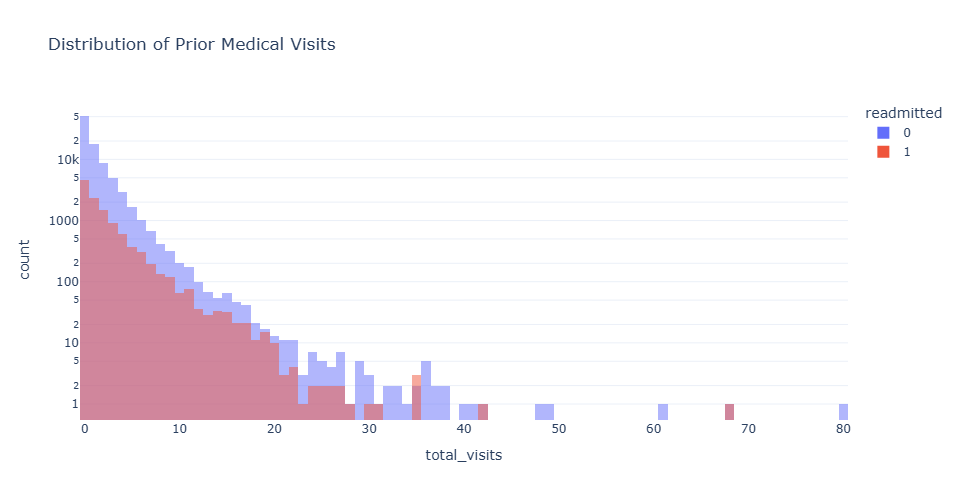

In [65]:
df['total_visits'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']

fig = px.histogram(df, color = 'readmitted', x = 'total_visits', barmode = 'overlay', log_y = True, template = 'plotly_white',
                  height = 500, width = 800, title = 'Distribution of Prior Medical Visits')
fig.show()

## Splitting Data

In [68]:
from sklearn.model_selection import train_test_split

np.random.seed(631)

#Columns are dropped to avoid data leakage, to reduce the size of our feature space (grouped columns), and to omit features with too many missing values
X = df.drop(columns = ["encounter_id", "patient_nbr", "weight", "max_glu_serum", "A1Cresult", "diag_1", "diag_2", "diag_3", "readmitted", "medical_specialty"])
y = df["readmitted"]

#We stratify on the target due to the class imbalance of our dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

## Pipeline Initialization

In [166]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

#Missing numeric values are replaced with column medians, then the values are scaled using the StandardScaler
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Missing categorical columns are replaced with the most frequent value, then converted to numeric datatypes using one-hot encoding
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

#Some features are booleans. These are already in the range of [0,1], so they do not need preprocessing
prep = ColumnTransformer([
    ('number', numeric_transformer, make_column_selector(dtype_include='number')),
    ('category', categorical_transformer, make_column_selector(dtype_include='object'))
], remainder = 'passthrough')

#The pipeline preprocesses the data, samples to address class imbalance, selects the most important features, then trains the classifier model
clf_pipeline = Pipeline([
    ('preprocess', prep),
    ('sampler', None),
    ('selector', VarianceThreshold(threshold = 0.3)),
    ('clf', DecisionTreeClassifier())
])

display(clf_pipeline)

,steps,"[('preprocess', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for 

## Experiment 1: Model Selection

In this experiment, we will test five different classifiers on this dataset: 
* Logistic Regression
* Decision Tree
* K-Nearest Neighbors
* Random Forest
* AdaBoost

We expect that the ensemble methods, Random Forest and AdaBoost, will perform best. Random Forest can learn nonlinear features better than linear models like Logistic Regression and generalize better than a single Decision Tree. The boosting technique of AdaBoost makes it better at classifying less frequent samples, reducing the impact of class imbalance on model performance. All model configurations will be tested using undersampled data, with features selected using a variance threshold of 0.3.

### Tuning

In [170]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

#Defines the metrics each model will be evaluated on
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

#Defines the hyperparameter combinations we will test for each model
param_grid = [
    {
        'clf': [LogisticRegression(max_iter = 1000, solver = 'saga')],
        'clf__l1_ratio': [0, 0.5, 1],
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf': [DecisionTreeClassifier()],
        'clf__splitter': ['best', 'random'],
        'clf__max_depth': [None, 10],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf': [KNeighborsClassifier()],
        'clf__n_neighbors': [3, 5, 7],
        'clf__weights': ['uniform', 'distance']
    },
    {
        'clf': [RandomForestClassifier()],
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [None, 10],
        'clf__max_features': ['sqrt', 'log2', None],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf': [AdaBoostClassifier()],
        'clf__n_estimators': [50, 100],
        'clf__learning_rate': [0.5, 1.0]
    }
]

#Evaluates each model configuration using 5-fold cross validation, refitting to maximize model recall
grid = GridSearchCV(clf_pipeline, param_grid, cv = 5, scoring = scoring, refit = 'f1')
grid.fit(X_train, y_train)

#Converts the CV-scores to a pandas dataframe
scores = pd.DataFrame(grid.cv_results_)
display(scores.head())

#Persists the scores to local memory
scores.to_csv('../data/tuning/cv_scores.csv', index = False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__C,param_clf__class_weight,param_clf__l1_ratio,param_clf__max_depth,param_clf__splitter,...,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,6.065732,2.289473,0.295458,0.003652,"LogisticRegression(max_iter=1000, solver='saga')",0.01,NaN,0.0,NaN,NaN,...,0.005242,53,0.635565,0.632348,0.639712,0.630011,0.634257,0.634379,0.003258,34
1,7.106424,2.845504,0.297221,0.004123,"LogisticRegression(max_iter=1000, solver='saga')",0.01,NaN,0.5,NaN,NaN,...,0.004103,54,0.636812,0.633592,0.640094,0.630913,0.634990,0.635280,0.003083,21
2,6.811462,2.777071,0.300236,0.005963,"LogisticRegression(max_iter=1000, solver='saga')",0.01,NaN,1.0,NaN,NaN,...,0.004613,57,0.636993,0.633629,0.640477,0.631306,0.635376,0.635556,0.003101,20
3,1.370133,0.137268,0.306872,0.006482,"LogisticRegression(max_iter=1000, solver='saga')",0.01,balanced,0.0,NaN,NaN,...,0.003099,20,0.635221,0.632614,0.640576,0.630830,0.634695,0.634787,0.003289,23
4,1.512707,0.052783,0.298055,0.005066,"LogisticRegression(max_iter=1000, solver='saga')",0.01,balanced,0.5,NaN,NaN,...,0.002938,10,0.636245,0.633586,0.640494,0.631417,0.634639,0.635276,0.003044,22


In [247]:
#Loads the scores from memory
scores = pd.read_csv('../data/tuning/cv_scores.csv')
#Gets the classifier name, using regex to split camel-casing into separate words ("RandomForest" -> "Random Forest")
scores['clf'] = scores['param_clf'].str.split('(').str[0].str.replace('Classifier', '').str.replace(r'([a-z])([A-Z])', r'\1 \2', regex = True)

#Displays the top 5 models by average recall
with pd.option_context('display.max_colwidth', None):
    display(scores[['clf', 'params', 'mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 
                'mean_test_f1', 'mean_test_roc_auc']].sort_values(by = 'mean_test_recall', ascending = False).nlargest(5, 'mean_test_recall'))

,clf,params,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
31,Decision Tree,"{'clf': DecisionTreeClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__splitter': 'random'}",1.312359,0.299588,0.624969,0.164146,0.576491,0.255407,0.638529
30,Decision Tree,"{'clf': DecisionTreeClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__splitter': 'best'}",1.594046,0.297793,0.624810,0.163096,0.569002,0.253073,0.629710
60,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': None, 'clf__n_estimators': 50}",24.714188,0.397552,0.685304,0.178943,0.507154,0.264530,0.653594
61,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': None, 'clf__n_estimators': 100}",48.524891,0.503679,0.687638,0.179223,0.502532,0.264193,0.655564
56,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__n_estimators': 50}",8.154035,0.398138,0.693583,0.181090,0.495927,0.265266,0.651056


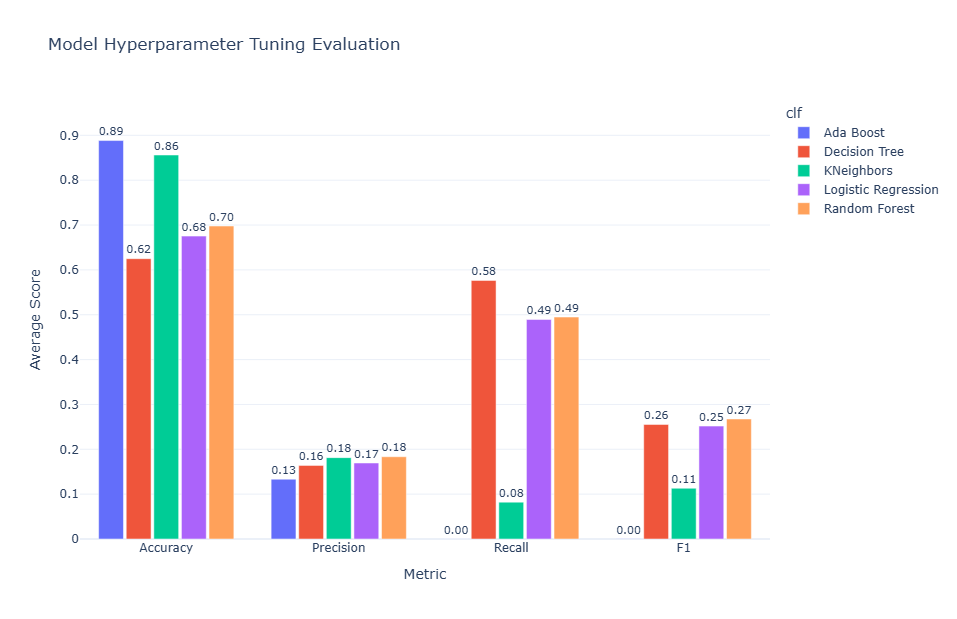

In [269]:
#Calculates each model's average accuracy, precision, recall, and f1-score across all configurations
best_scores = pd.melt(scores.groupby('clf').apply(lambda x: x.nlargest(1, 'mean_test_f1'))[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].reset_index().drop(columns = 'level_1'),
       id_vars = 'clf', var_name = 'metric', value_name = 'avg_score')

#Plots the average values as a bar chart, encoding model as bar color, average score as bar height, 
#and metric as bar x
fig = px.bar(best_scores, x = 'metric', y = 'avg_score', color = 'clf', template = 'plotly_white',
            height = 600, width = 1000, text_auto = True, barmode = 'group', title = 'Model Hyperparameter Tuning Evaluation')
#Adds text labels above each bar
fig.update_traces(textposition='outside', texttemplate='%{y:.2f}')
fig.update_layout(yaxis_title = 'Average Score', xaxis_title = 'Metric', bargroupgap = 0.1)

#fig.for_each_annotation(lambda a: a.update(text=a.text.split("mean_test_")[-1].title()))
fig.update_xaxes(
    tickmode = 'array',
    tickvals = ['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1'],
    ticktext = ['Accuracy', 'Precision', 'Recall', 'F1']
)

fig.show()

This chart visualizes the performance metrics of the model configurations that maximize F1-score (balance precision and recall). Immediately, we can see the difficulties in training and evaluating models that result from the high class imbalance. Most patients belong to the negative class; models predict the majority class more often, resulting in misleading high-accuracy rates. A low number of readmitted patients and lack of high correlations between any features and the target explains the low precision scores. Without using any sampling techniques, we find that decision tree outperforms all other models on recall. We will investigate what impact undersampling has on these results.

In [218]:
from imblearn.under_sampling import RandomUnderSampler

#Replaces the sampling technique
clf_pipeline.set_params(sampler=RandomUnderSampler())

#Evaluates each model configuration using 5-fold cross validation, refitting to maximize model recall
grid = GridSearchCV(clf_pipeline, param_grid, cv = 5, scoring = scoring, refit = 'f1')
grid.fit(X_train, y_train)

#Converts the CV-scores to a pandas dataframe
scores = pd.DataFrame(grid.cv_results_)
display(scores.head())

#Persists the scores to local memory
scores.to_csv('../data/tuning/cv_scores_undersample.csv', index = False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__C,param_clf__class_weight,param_clf__l1_ratio,param_clf__max_depth,param_clf__splitter,...,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,1.094735,0.030932,0.321161,0.010803,"LogisticRegression(max_iter=1000, solver='saga')",0.01,NaN,0.0,NaN,NaN,...,0.003131,19,0.634888,0.633123,0.641259,0.631091,0.636510,0.635374,0.003452,19
1,1.160969,0.097585,0.319440,0.015806,"LogisticRegression(max_iter=1000, solver='saga')",0.01,NaN,0.5,NaN,NaN,...,0.003284,30,0.637125,0.633493,0.639554,0.631140,0.634392,0.635141,0.002922,21
2,1.053793,0.029943,0.323708,0.019551,"LogisticRegression(max_iter=1000, solver='saga')",0.01,NaN,1.0,NaN,NaN,...,0.002758,18,0.637277,0.633157,0.640726,0.632921,0.634236,0.635663,0.002969,18
3,1.144017,0.036477,0.326830,0.008038,"LogisticRegression(max_iter=1000, solver='saga')",0.01,balanced,0.0,NaN,NaN,...,0.003077,36,0.635931,0.630898,0.639088,0.630179,0.636949,0.634609,0.003484,25
4,1.082769,0.041169,0.321152,0.007103,"LogisticRegression(max_iter=1000, solver='saga')",0.01,balanced,0.5,NaN,NaN,...,0.001668,27,0.635579,0.633569,0.639766,0.632747,0.634136,0.635159,0.002482,20


In [285]:
#Loads the scores from memory
scores = pd.read_csv('../data/tuning/cv_scores_undersample.csv')
#Gets the classifier name, using regex to split camel-casing into separate words ("RandomForest" -> "Random Forest")
scores['clf'] = scores['param_clf'].str.split('(').str[0].str.replace('Classifier', '').str.replace(r'([a-z])([A-Z])', r'\1 \2', regex = True)

#Displays the top 5 models by average recall
with pd.option_context('display.max_colwidth', None):
    display(scores[['clf', 'params', 'mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 
                'mean_test_f1', 'mean_test_roc_auc']].sort_values(by = 'mean_test_recall', ascending = False).nlargest(5, 'mean_test_recall'))

,clf,params,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
48,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': None, 'clf__max_depth': 10, 'clf__max_features': None, 'clf__n_estimators': 50}",6.310864,0.431039,0.606594,0.165215,0.622936,0.261148,0.658183
49,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': None, 'clf__max_depth': 10, 'clf__max_features': None, 'clf__n_estimators': 100}",11.640531,0.545473,0.604210,0.164199,0.622274,0.259728,0.658046
60,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': None, 'clf__n_estimators': 50}",6.216246,0.430315,0.614504,0.167550,0.618425,0.263658,0.658766
61,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': None, 'clf__n_estimators': 100}",11.406735,0.548381,0.617476,0.168392,0.616334,0.264483,0.660550
46,Random Forest,"{'clf': RandomForestClassifier(), 'clf__class_weight': None, 'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__n_estimators': 50}",2.653959,0.443562,0.614357,0.165961,0.609949,0.260922,0.652510


It appears that on average, Random Forest models had the highest recall. These models are showing poor precision, likely due to the undersampling method used to address class imbalance. The models are trained to be more sensitive to the minority class, reducing their ability to accurately distinguish true and false positives. 

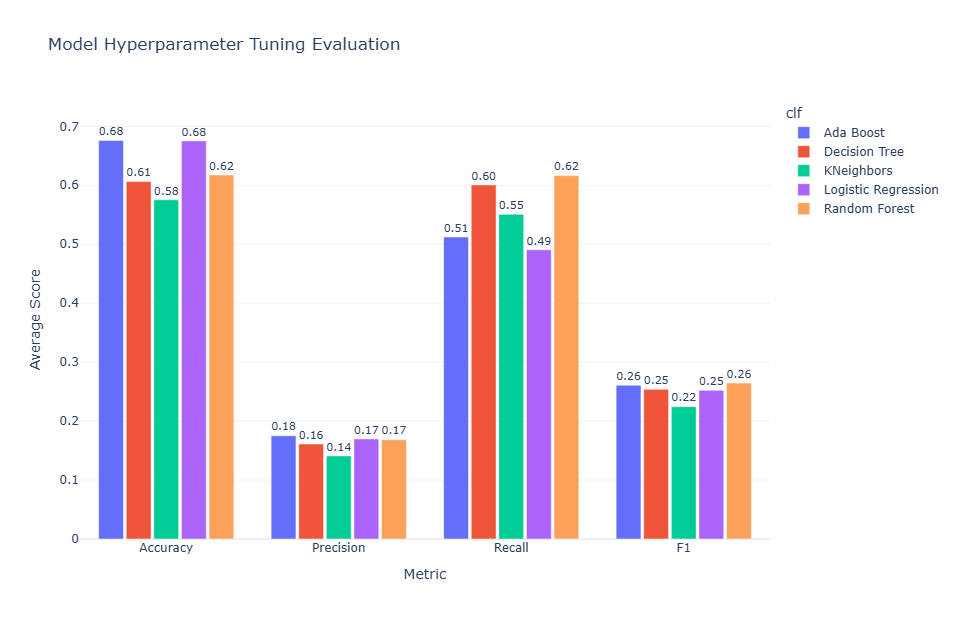

In [288]:
#Calculates each model's average accuracy, precision, recall, and f1-score across all configurations
#avg_scores = pd.melt(scores.groupby('clf')[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].reset_index(),
#       id_vars = 'clf', var_name = 'metric', value_name = 'avg_score')
best_scores = pd.melt(scores.groupby('clf').apply(lambda x: x.nlargest(1, 'mean_test_f1'))[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].reset_index().drop(columns = 'level_1'),
       id_vars = 'clf', var_name = 'metric', value_name = 'avg_score')

#Plots the average values as a bar chart, encoding model as bar color, average score as bar height, 
#and metric as bar x
fig = px.bar(best_scores, x = 'metric', y = 'avg_score', color = 'clf', template = 'plotly_white',
            height = 600, width = 1000, text_auto = True, barmode = 'group', title = 'Model Hyperparameter Tuning Evaluation')
#Adds text labels above each bar
fig.update_traces(textposition='outside', texttemplate='%{y:.2f}')
fig.update_layout(yaxis_title = 'Average Score', xaxis_title = 'Metric', bargroupgap = 0.1)

#fig.for_each_annotation(lambda a: a.update(text=a.text.split("mean_test_")[-1].title()))
fig.update_xaxes(
    tickmode = 'array',
    tickvals = ['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1'],
    ticktext = ['Accuracy', 'Precision', 'Recall', 'F1']
)

fig.show()

The results are strikingly similar - high accuracy/recall and low precision/F1 scores. Notably, undersampling has improved the performance of AdaBoost and KNeighbors. All models struggle with precision, resulting in low F1-scores. While AdaBoost and Logistic Regression outperform Random Forest on accuracy, we will use Random Forest due to its high average recall. 

To confirm these findings, we will train the model configurations that maximize recall, then compare the results in a precision-recall curve. This is used in place of an ROC curve, as a precision-recall curve focuses only on the positive class and is unaffected by false positives. 

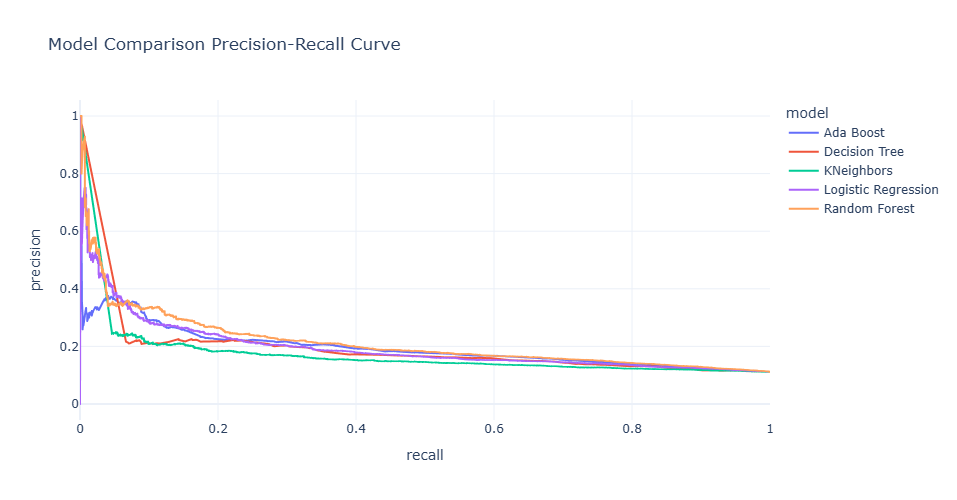

In [291]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import precision_recall_curve

#Gets the hyperparameters for each model that maximize recall
best_recall = scores.groupby('clf').apply(lambda x: x.nlargest(1, 'mean_test_recall'))['params']

#Splits the training data into train and validation sets
X_train_pr, X_valid_pr, y_train_pr, y_valid_pr = train_test_split(X_train, y_train, test_size = 0.2, stratify = y_train)

#Initializes an empty list to store the precision-recall results
pr_res = []

for index, model, params in best_recall.reset_index()[['clf', 'params']].itertuples():
    #Initializes a dict to store the current model's results
    res = {}
    #Sets the model name attribute
    res['model'] = model
    
    #Updates the pipeline with the current parameters
    clf_pipeline.set_params(**eval(params))

    #Trains the pipeline and predicts using the validation set
    clf_pipeline.fit(X_train_pr, y_train_pr)
    y_prob = clf_pipeline.predict_proba(X_valid_pr)[:, 1]

    #Calculates precision and recall using the sklearn precision_recall_curve function
    precision, recall, thresholds = precision_recall_curve(y_valid_pr, y_prob)

    #Stores the results
    res['precision'] = precision
    res['recall'] = recall
    res['thresholds'] = thresholds
    pr_res.append(res)

#Expands each classifier's precision and recall values from lists to individual rows
pr_frame = pd.DataFrame(pr_res).explode(['precision', 'recall'])

#Plots each model's PR curve on the same figure
fig = px.line(pr_frame, x = 'recall', y = 'precision', color = 'model', template = 'plotly_white',
             height = 500, width = 800, title = 'Model Comparison Precision-Recall Curve')


fig.show()

While the concave-upward decreasing curves on this figure emphasizes the poor precision of our classifiers, it confirms our choice of selected model. Random Forest maximizes recall with little loss in precision compared to AdaBoost and Logistic Regression.

To choose the hyperparameters of our Random Forest model, we will create a visualization to compare the mean test recall across all configurations. 

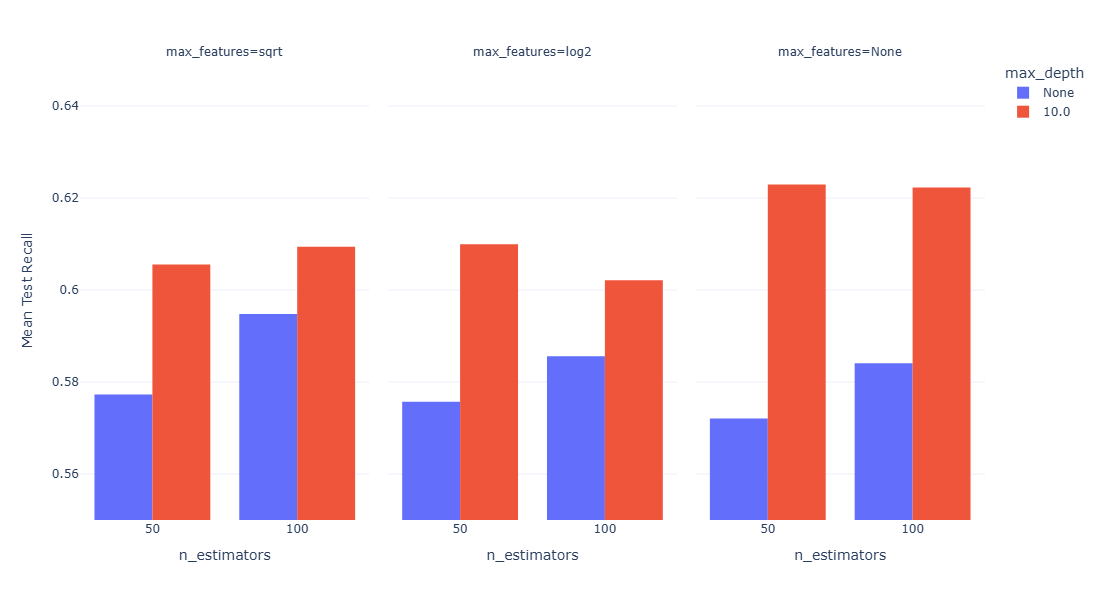

In [305]:
#Retrieves the hyperparameters and recall scores of all Random Forest configurations
forest_performance = scores.loc[scores['clf'] == 'Random Forest', 
    ['param_clf__n_estimators', 'param_clf__max_depth', 'param_clf__max_features', 'mean_test_recall']]

#Renames the hyperparameter columns to remove 'param_clf__'
forest_performance.columns = ['n_estimators', 'max_depth', 'max_features', 'mean_test_recall']
#Some hyperparameters have 'None' as an option. We'll convert them to strings to ensure these values are displayed
forest_performance['max_depth'] = forest_performance['max_depth'].fillna('None').astype(str)
forest_performance['max_features'] = forest_performance['max_features'].fillna('None').astype(str)

#Plots the performance as a histogram
fig = px.histogram(forest_performance, x = 'n_estimators', y = 'mean_test_recall', color = 'max_depth', facet_col = 'max_features',
                  barmode = 'group', height = 600, width = 1000, template = 'plotly_white', histfunc = 'max')
fig.update_xaxes(type = 'category')
#Limits the y-axis range to emphasize the models that maximize performance
fig.update_yaxes(range=[0.55, 0.65])
fig.update_layout(yaxis=dict(title="Mean Test Recall"))
fig.show()

Though recall is very similar across all model configurations, the model with max_depth=10, max_features=None, n_estimators=50 resulted in the highest mean test recall (0.623).

## Experiment 2: Sampling Method Tuning

In addition to random under sampling, we will evaluate how models perform using random over sampling and SMOTE. 

In [446]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

param_grid = [{
    'clf': [RandomForestClassifier(max_depth = 10, max_features = None, n_estimators = 50)],
    'sampler': [RandomUnderSampler(), RandomOverSampler(), SMOTE()]
}]

#Evaluates each sampling method's performance using 5-fold cross validation, refitting on f1
#Here, we refit on f1 over recall to improve precision without sacrificing recall performance
grid = GridSearchCV(clf_pipeline, param_grid, cv = 5, scoring = scoring, refit = 'f1')
grid.fit(X_train, y_train)

sampler_scores = pd.DataFrame(grid.cv_results_)
sampler_scores.to_csv('../data/tuning/sampler_scores.csv', index = False)
display(sampler_scores[['param_sampler', 'mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']].sort_values(by = 'mean_test_recall', ascending = False).nlargest(5, 'mean_test_recall'))

,param_sampler,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
0,RandomUnderSampler(),7.167765,0.443074,0.616863,0.167111,0.610607,0.262391,0.659129
1,RandomOverSampler(),59.754114,0.441349,0.654031,0.172897,0.554809,0.263593,0.655266
2,SMOTE(),59.345580,0.446587,0.869061,0.304508,0.134383,0.186225,0.645093


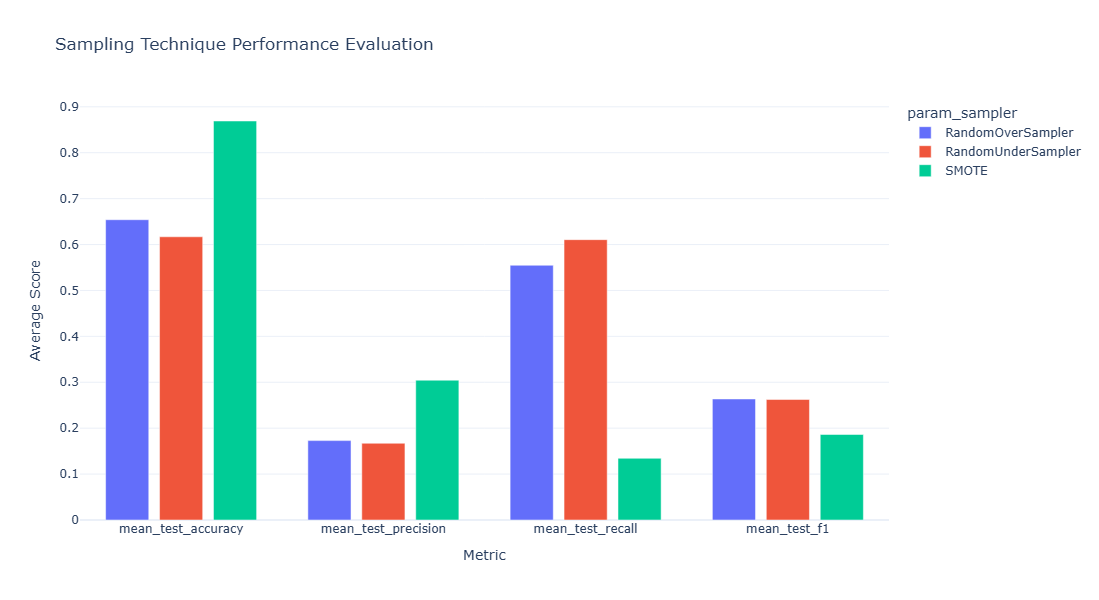

In [131]:
sampler_scores = pd.read_csv('../data/tuning/sampler_scores.csv')
sampler_scores['param_sampler'] = sampler_scores['param_sampler'].str.replace('()', '')

#Calculates each sampling method's average accuracy, precision, recall, and f1-score
avg_scores = pd.melt(sampler_scores.groupby('param_sampler')[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].mean().reset_index(),
       id_vars = 'param_sampler', var_name = 'metric', value_name = 'avg_score')

#Plots the average scores as a bar chart
fig = px.bar(avg_scores, x = 'metric', y = 'avg_score', color = 'param_sampler', template = 'plotly_white',
            height = 600, width = 1000, barmode = 'group', title = 'Sampling Technique Performance Evaluation')


fig.update_layout(xaxis_title = 'Metric', yaxis_title = 'Average Score', bargroupgap = 0.2)

fig.update_xaxes(
    tickmode = 'array',
    tickvals = ['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1'],
    ticktext = ['Accuracy', 'Precision', 'Recall', 'F1']
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("mean_test_")[-1].title()))

fig.show()

Undersampling and oversampling resulted in similar performance, with undersampling having lower fit times and higher recall. While SMOTE greatly improved model accuracy and precision, this technique resulted in much lower recall. Therefore, we will continue using random under sampling to address the class imbalance during training. 

## Experiment 3: Feature Selection Tuning

In [151]:
from sklearn.feature_selection import SelectKBest, SelectFromModel
from sklearn.svm import LinearSVC

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

param_grid = [
    {
        'clf': [RandomForestClassifier(max_depth = 10, max_features = None, n_estimators = 50)],
        'selector': [VarianceThreshold()],
        'selector__threshold': [0.1, 0.3, 0.5]
    },
    {
        'clf': [RandomForestClassifier(max_depth = 10, max_features = None, n_estimators = 50)],
        'selector': [SelectKBest()],
        'selector__k': ['all', 10, 20]
    },
    {
        'clf': [RandomForestClassifier(max_depth = 10, max_features = None, n_estimators = 50)],
        'selector': [SelectFromModel(LinearSVC(C=0.01, random_state=631, max_iter=10000), threshold="median")]
    }
]

#Evaluates each feature selection technique's performance using 5-fold cross validation, refitting on f1
#Here, we refit on f1 over recall to improve precision without sacrificing recall performance
grid = GridSearchCV(clf_pipeline, param_grid, cv = 5, scoring = scoring, refit = 'f1')
grid.fit(X_train, y_train)

selection_scores = pd.DataFrame(grid.cv_results_)
selection_scores.to_csv('../data/tuning/selection_scores.csv', index = False)
display(selection_scores[['param_selector', 'mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']].sort_values(by = 'mean_test_recall', ascending = False).nlargest(5, 'mean_test_recall'))

C:\Users\Matt\anaconda3\envs\dsci631\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\Matt\anaconda3\envs\dsci631\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\Matt\anaconda3\envs\dsci631\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\Matt\anaconda3\envs\dsci631\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\Matt\anaconda3\envs\dsci631\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\Matt\anaconda3\envs\dsci631\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py

,param_selector,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
1,VarianceThreshold(),5.923689,0.426395,0.610966,0.166237,0.619083,0.262062,0.657892
2,VarianceThreshold(),5.961763,0.450708,0.612182,0.166147,0.615894,0.261663,0.659218
5,SelectKBest(),6.116403,0.437019,0.612477,0.165632,0.611930,0.260643,0.656367
6,"SelectFromModel(estimator=LinearSVC(C=0.01, ma...",8.644398,0.466029,0.618508,0.167767,0.610389,0.263161,0.662151
3,SelectKBest(),15.274362,0.533500,0.628187,0.171254,0.606648,0.267029,0.664782


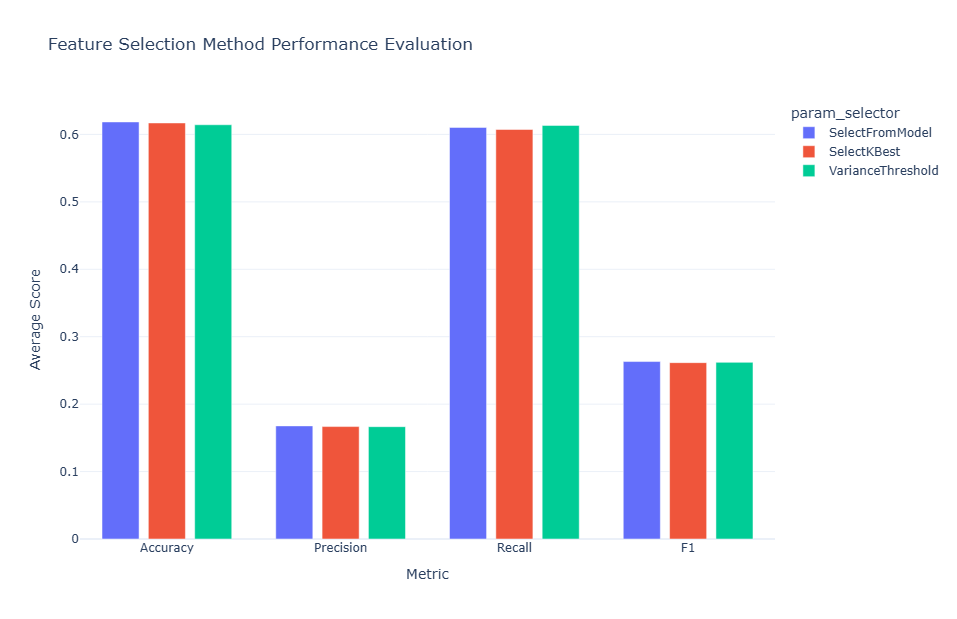

In [155]:
selector_scores = pd.read_csv('../data/tuning/selection_scores.csv')
selector_scores['param_selector'] = selector_scores['param_selector'].str.split('(').str[0]

#Calculates each sampling method's average accuracy, precision, recall, and f1-score
avg_scores = pd.melt(selector_scores.groupby('param_selector')[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].mean().reset_index(),
       id_vars = 'param_selector', var_name = 'metric', value_name = 'avg_score')

#Plots the average scores as a bar chart
fig = px.bar(avg_scores, x = 'metric', y = 'avg_score', color = 'param_selector', template = 'plotly_white',
            height = 600, width = 1000, barmode = 'group', title = 'Feature Selection Method Performance Evaluation')


fig.update_layout(xaxis_title = 'Metric', yaxis_title = 'Average Score', bargroupgap = 0.2)

fig.update_xaxes(
    tickmode = 'array',
    tickvals = ['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1'],
    ticktext = ['Accuracy', 'Precision', 'Recall', 'F1']
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("mean_test_")[-1].title()))

fig.show()

Our findings indicate that the feature selection technique has little-to-no impact on model performance. Variance Threshold has the highest average recall and a reduced mean fit time compared to Select-From-Model, so we will use that technique in our final pipeline.

## Final Evaluation

All that is left is to train the model using the tuned pipeline, then evaluate on the test set.

In [161]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, classification_report

tuned_pipe = Pipeline([
    ('preprocess', prep),
    ('sampler', RandomUnderSampler()),
    ('selector', VarianceThreshold(threshold = 0.3)),
    ('clf', RandomForestClassifier(max_depth = 10, n_estimators = 50, max_features = None))
])

#Fits the pipeline on the training set
tuned_pipe.fit(X_train, y_train)

#Evaluates on the test set
y_pred = tuned_pipe.predict(X_test)

#Prints the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.59      0.72     18083
           1       0.17      0.65      0.26      2271

    accuracy                           0.59     20354
   macro avg       0.55      0.62      0.49     20354
weighted avg       0.85      0.59      0.67     20354



The results indicate higher performance on the majority class and poor performance on predicting the minority (positive) class. Though our dataset is highly imbalanced, the importance of the minority class means that the macro average metrics provide a better understanding of overall performance. Despite our tuning, the precision and recall scores are well below the expected threshold for medical machine learning models. For future analyses, we would investigate more powerful deep-learning models to improve predictions. 

Below, we include a feature importance plot to visualize how our model makes its predictions.

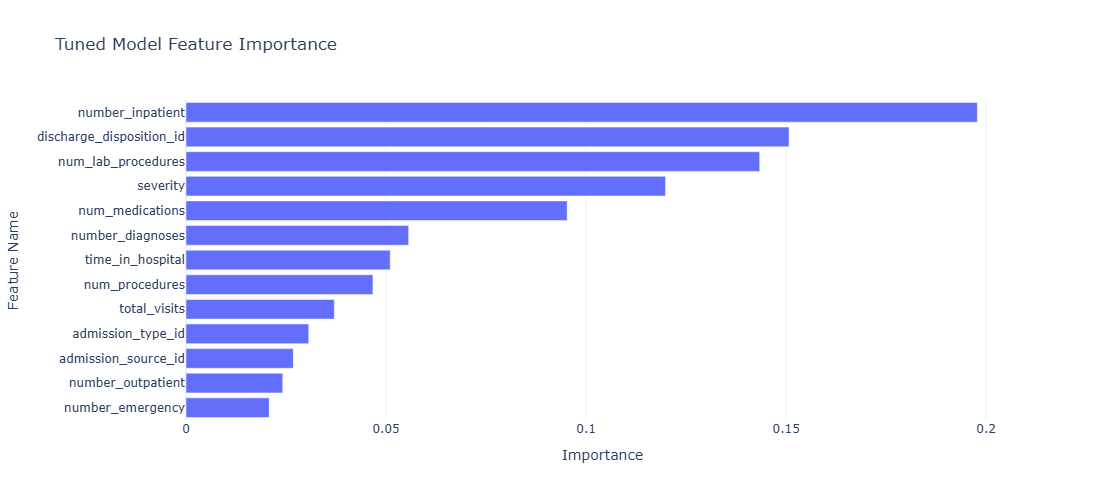

In [163]:
#Gets the feature names and Random Forest importances
feature_importance = pd.DataFrame({
    'feature': tuned_pipe[:-1].get_feature_names_out(),
    'importance': tuned_pipe[-1].feature_importances_
})

#Each feature_name contains a prefix describing its preprocessing path. We store this as the feature dtype, then remove it from
#the name
feature_importance['dtype'] = feature_importance['feature'].str.split('__').str[0]
feature_importance['dtype'] = feature_importance['dtype'].str.replace('remainder', 'boolean')

feature_importance['feature'] = feature_importance['feature'].str.split('__').str[1]

#Plots the importance of the top 15 features as a bar chart
fig = px.bar(feature_importance.nlargest(15, 'importance'), x = 'importance', y = 'feature', template = 'plotly_white', height = 500, width = 800,
            title = 'Tuned Model Feature Importance')
fig.update_layout(xaxis_title = 'Importance', yaxis_title = 'Feature Name')
fig.update_yaxes(categoryorder = 'total ascending')
fig.show()